
# 🚨 알트불장 화재경보기 v1.1

**목표:** 알트코인 가격이 이미 크게 오른 뒤가 아니라, **1시간·4시간 단위로 시장 전반에 거래량과 상대강도가 번지는 순간**을 탐지합니다.

## 사용법
1. 이 노트북에서 `런타임 → 모두 실행`을 누릅니다.
2. `현재 단계`와 `화재 점수`를 확인합니다.
3. 첫 실행 후 **1~2시간 뒤 마지막 셀을 다시 실행**하면 점수 급가속 여부가 표시됩니다.

## 단계
- ⚪ 대기
- 🟡 예열·연기 감지
- 🚨 점화 직전·초기
- 🔥 알트불장 점화
- 🔥 폭발적 알트불장

API 키와 회원가입은 필요 없습니다. CoinGecko·CoinPaprika·Binance의 공개 시장데이터만 사용하며, 일부 연결이 실패해도 프로그램은 멈추지 않습니다.


> v1.1: Colab 한글 폰트 경고를 없애기 위해 그래프 글자만 영문으로 표시합니다. 표와 결과 설명은 한글 그대로입니다.

              🚨 알트불장 화재경보기
현재 단계 : 🟡 예열·연기 감지
화재 점수 : 37.1/100
데이터 범위: 100% | 광범위 시장: CoinGecko 공개 API
Binance 보조검사: 정상 18개 종목
점수 변화 : 첫 실행 — 1~2시간 뒤 다시 실행하면 급가속을 비교합니다.
판정 설명 : 일부 선행 신호가 보이지만 확산 확인이 더 필요합니다.
기준 시각 : 2026-08-06 12:06:33 UTC
------------------------------------------------------------------------
• 아직 선행경보입니다. ETH/BTC와 시장 폭이 함께 개선되는지 기다립니다.

[핵심 점화 지표]


,name,value,component,weight,상태
0,알트 상승 확산 1h,57.00,48.6,18,개선
1,BTC 초과 종목 1h,57.00,53.1,15,개선
2,유동성알트 확산 4h,38.89,0.0,10,약함
3,BTC 초과 종목 4h,50.00,33.3,10,약함
4,ETH/BTC 1h,0.30,40.0,8,약함
5,ETH/BTC 24h,1.19,43.8,5,약함
6,단기 가속도,0.10,38.5,12,약함
7,대형→중형 확산,50.00,42.9,10,약함
8,거래량 급증,27.78,39.5,7,약함
9,동시 돌파,0.00,0.0,5,약함



[일반인용 핵심 숫자]


,지표,값,단위
0,BTC 1시간,0.00,%
1,BTC 24시간,0.80,%
2,ETH/BTC 상대강도 1시간,0.30,%
3,알트 상승 비율 1시간,57.00,%
4,BTC 초과 알트 비율 1시간,57.00,%
5,대형알트 상승 비율 1시간,50.00,%
6,중형알트 상승 비율 1시간,53.33,%
7,단기 가속도,0.10,%p
8,거래량 급증 종목 비율,27.78,%
9,20시간 고점 돌파 비율,0.00,%



[현재 불꽃 후보 — 매수 추천이 아니라 상대강도 관찰표]


,rank,symbol,name,ret_1h,ret_24h,vs_btc_1h,turnover_pct,ignition_score
0,108.0,BTW,Bitway,3.9,22.6,3.9,6.44,87.95
1,111.0,UB,Unibase,3.1,-3.5,3.1,22.40,64.95
2,92.0,BEAT,Audiera,3.2,-26.0,3.2,4.97,61.60
3,71.0,ENA,Ethena,1.6,0.5,1.6,12.02,44.33
4,16.0,ADA,Cardano,1.6,-1.5,1.6,5.35,38.60
5,113.0,VIRTUAL,Virtuals Protocol,0.8,1.6,0.8,10.31,33.20
6,53.0,AAVE,Aave,0.9,-3.1,0.9,13.54,32.65
7,90.0,LIT,Lighter,0.6,4.9,0.6,5.52,31.11
8,38.0,UNI,Uniswap,0.7,1.5,0.7,9.92,31.03
9,95.0,币安人生,币安人生 (BinanceLife),0.7,7.9,0.7,2.12,31.02



[연결 상태]
• Binance 일부 종목 실패 2건


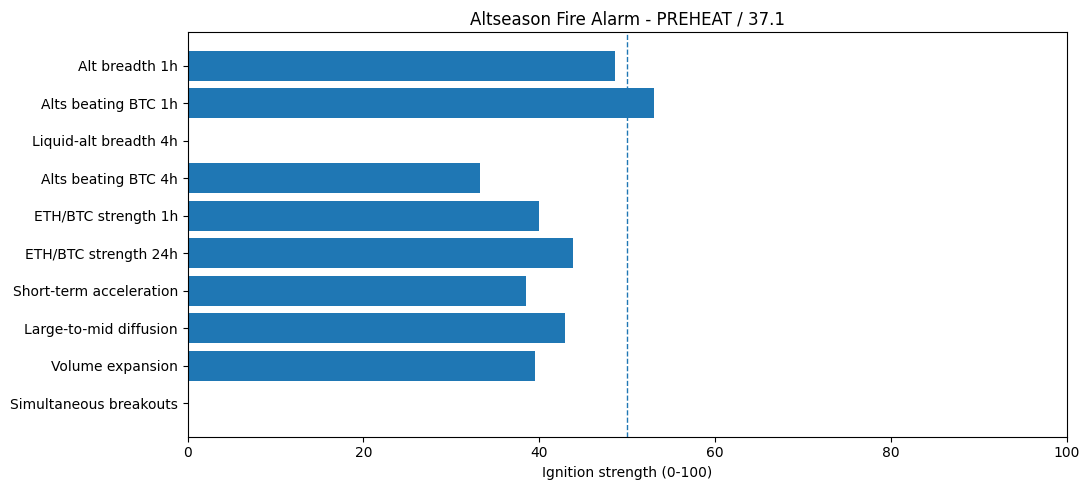

In [1]:

# ============================================================
# 알트불장 화재경보기 v1.0
# - API KEY 불필요
# - CoinGecko 공개 API 우선, CoinPaprika 자동 대체
# - Binance 공개 시장데이터는 4시간/거래량/돌파 보조지표로만 사용
# - 어떤 데이터원이 막혀도 프로그램은 중단되지 않음
# ============================================================

from __future__ import annotations

import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from IPython.display import display

# -----------------------------
# 사용자 조정값
# -----------------------------
TOP_ALT_COUNT = 100          # 시장 폭 계산에 사용할 상위 알트 수
BINANCE_SAMPLE_COUNT = 20    # 1시간봉 정밀검사 대상 유동성 상위 알트 수
MIN_MARKET_CAP_USD = 30_000_000
REQUEST_TIMEOUT = 12
HISTORY_FILE = Path("/content/alt_fire_alarm_history.csv")

# 스테이블코인·금 연동·중복 래핑자산 제외
EXCLUDED_SYMBOLS = {
    "USDT","USDC","USDE","DAI","FDUSD","TUSD","USDS","BUSD","PYUSD",
    "FRAX","USDD","GUSD","LUSD","USD0","USD1","EURC","XAUT","PAXG",
    "WBTC","WETH","STETH","WSTETH","CBETH","RETH","WEETH","EZETH"
}
EXCLUDED_NAME_WORDS = (
    "wrapped ", "bridged ", "staked ", "liquid staked",
    "binance-peg", "wormhole", "tokenized"
)

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "AltseasonFireAlarm/1.0 educational-colab",
    "Accept": "application/json,text/plain,*/*",
})

def short_error(exc: Exception) -> str:
    text = f"{type(exc).__name__}: {exc}"
    return text[:180] + ("..." if len(text) > 180 else "")

def get_json(
    url: str,
    params: Optional[dict] = None,
    retries: int = 2,
    timeout: int = REQUEST_TIMEOUT,
) -> Any:
    """429·5xx는 잠시 쉬고 재시도. 최종 실패 시 예외를 상위 fallback으로 전달."""
    last_exc: Optional[Exception] = None
    for attempt in range(retries + 1):
        try:
            response = SESSION.get(url, params=params, timeout=timeout)
            if response.status_code == 429:
                wait = min(float(response.headers.get("Retry-After", 2 + attempt * 2)), 8)
                time.sleep(wait)
                last_exc = RuntimeError("HTTP 429 요청 제한")
                continue
            response.raise_for_status()
            return response.json()
        except Exception as exc:
            last_exc = exc
            if attempt < retries:
                time.sleep(1.2 * (attempt + 1))
    raise RuntimeError(short_error(last_exc or RuntimeError("알 수 없는 통신 오류")))

def to_number(value: Any) -> float:
    try:
        value = float(value)
        return value if np.isfinite(value) else np.nan
    except Exception:
        return np.nan

# ============================================================
# 1. 광범위 시장 데이터: CoinGecko -> CoinPaprika fallback
# ============================================================

def fetch_coingecko_market() -> pd.DataFrame:
    raw = get_json(
        "https://api.coingecko.com/api/v3/coins/markets",
        params={
            "vs_currency": "usd",
            "order": "market_cap_desc",
            "per_page": 150,
            "page": 1,
            "sparkline": "false",
            "price_change_percentage": "1h,24h,7d",
        },
        retries=2,
    )
    if not isinstance(raw, list) or len(raw) < 20:
        raise RuntimeError("CoinGecko 시장 데이터가 충분하지 않습니다.")

    rows = []
    for x in raw:
        rows.append({
            "id": str(x.get("id", "")),
            "symbol": str(x.get("symbol", "")).upper(),
            "name": str(x.get("name", "")),
            "rank": to_number(x.get("market_cap_rank")),
            "price": to_number(x.get("current_price")),
            "market_cap": to_number(x.get("market_cap")),
            "volume_24h": to_number(x.get("total_volume")),
            "ret_1h": to_number(x.get("price_change_percentage_1h_in_currency")),
            "ret_24h": to_number(x.get("price_change_percentage_24h_in_currency")),
            "ret_7d": to_number(x.get("price_change_percentage_7d_in_currency")),
        })
    return pd.DataFrame(rows)

def fetch_coinpaprika_market() -> pd.DataFrame:
    raw = get_json("https://api.coinpaprika.com/v1/tickers", retries=2)
    if not isinstance(raw, list) or len(raw) < 20:
        raise RuntimeError("CoinPaprika 시장 데이터가 충분하지 않습니다.")

    rows = []
    for x in raw:
        usd = (x.get("quotes") or {}).get("USD") or {}
        rows.append({
            "id": str(x.get("id", "")),
            "symbol": str(x.get("symbol", "")).upper(),
            "name": str(x.get("name", "")),
            "rank": to_number(x.get("rank")),
            "price": to_number(usd.get("price")),
            "market_cap": to_number(usd.get("market_cap")),
            "volume_24h": to_number(usd.get("volume_24h")),
            "ret_1h": to_number(usd.get("percent_change_1h")),
            "ret_24h": to_number(usd.get("percent_change_24h")),
            "ret_7d": to_number(usd.get("percent_change_7d")),
        })
    return pd.DataFrame(rows)

def fetch_market_with_fallback() -> Tuple[pd.DataFrame, str, List[str]]:
    warnings: List[str] = []
    try:
        return fetch_coingecko_market(), "CoinGecko 공개 API", warnings
    except Exception as exc:
        warnings.append("CoinGecko 실패: " + short_error(exc))

    try:
        return fetch_coinpaprika_market(), "CoinPaprika 공개 API", warnings
    except Exception as exc:
        warnings.append("CoinPaprika 실패: " + short_error(exc))

    raise RuntimeError(" | ".join(warnings))

def clean_market(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in ["rank","price","market_cap","volume_24h","ret_1h","ret_24h","ret_7d"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out["symbol"] = out["symbol"].astype(str).str.upper().str.strip()
    out["name_l"] = out["name"].astype(str).str.lower()
    out = out.drop_duplicates("symbol", keep="first")
    out = out[out["market_cap"].fillna(0) >= MIN_MARKET_CAP_USD]
    out = out[~out["symbol"].isin(EXCLUDED_SYMBOLS)]
    out = out[~out["name_l"].apply(lambda s: any(word in s for word in EXCLUDED_NAME_WORDS))]
    out = out.sort_values(["rank", "market_cap"], ascending=[True, False], na_position="last")
    return out.reset_index(drop=True)

# ============================================================
# 2. Binance 보조검사: 1h 봉에서 4h·거래량·돌파 계산
# ============================================================

BINANCE_BASES = [
    "https://data-api.binance.vision",
    "https://api.binance.com",
    "https://api-gcp.binance.com",
    "https://api1.binance.com",
]

def fetch_binance_klines(symbol: str, limit: int = 30) -> List[list]:
    errors = []
    for base in BINANCE_BASES:
        try:
            data = get_json(
                base + "/api/v3/klines",
                params={"symbol": symbol, "interval": "1h", "limit": limit},
                retries=0,
                timeout=8,
            )
            if isinstance(data, list) and len(data) >= 26:
                return data
            errors.append(f"{base}: 데이터 부족")
        except Exception as exc:
            errors.append(f"{base}: {short_error(exc)}")
    raise RuntimeError(" / ".join(errors[:2]))

def analyze_one_kline(symbol: str) -> Dict[str, Any]:
    rows = fetch_binance_klines(symbol, 30)

    # 마지막 행은 아직 진행 중일 수 있으므로, 직전 완성봉을 사용
    completed = rows[:-1]
    if len(completed) < 25:
        raise RuntimeError("완성된 1시간봉 부족")

    close_now = to_number(completed[-1][4])
    close_1h = to_number(completed[-2][4])
    close_4h = to_number(completed[-5][4])
    close_24h = to_number(completed[-25][4])

    previous_20 = completed[-21:-1]
    current_quote_volume = to_number(completed[-1][7])
    previous_quote_volumes = [to_number(r[7]) for r in previous_20]
    previous_highs = [to_number(r[2]) for r in previous_20]

    avg_prev_volume = float(np.nanmean(previous_quote_volumes))
    previous_high = float(np.nanmax(previous_highs))

    return {
        "symbol": symbol,
        "ret_1h_binance": (close_now / close_1h - 1) * 100 if close_1h else np.nan,
        "ret_4h_binance": (close_now / close_4h - 1) * 100 if close_4h else np.nan,
        "ret_24h_binance": (close_now / close_24h - 1) * 100 if close_24h else np.nan,
        "volume_ratio_1h": current_quote_volume / avg_prev_volume if avg_prev_volume > 0 else np.nan,
        "breakout_20h": bool(close_now > previous_high) if np.isfinite(previous_high) else False,
    }

def fetch_binance_sample(alt_df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str], Dict[str, Any]]:
    """Binance 보조표본을 가능한 한 20개 '성공 표본'으로 채운다.

    기존 방식은 거래량 상위 20개를 딱 한 번만 시도해서 3개가 실패하면
    17개 표본으로 점수를 내면서도 데이터 범위를 100%로 표시했다.
    이제는 후보를 더 넓게 잡아 실패 종목을 다음 유동성 종목으로 보충하고,
    그래도 20개를 못 채우면 성공률만큼 보조지표 가중치를 낮춘다.
    """
    warnings: List[str] = []
    candidates = (
        alt_df.sort_values("volume_24h", ascending=False)["symbol"]
        .dropna().astype(str).drop_duplicates().tolist()
    )
    candidates = [s for s in candidates if s not in {"BTC", "ETH"}]

    results: List[Dict[str, Any]] = []
    successful_alts = 0
    attempted_alts = 0

    # BTC/ETH는 기준자산. 실패해도 알트 표본 수에는 포함하지 않는다.
    for base_symbol in ["BTC", "ETH"]:
        pair = base_symbol + "USDT"
        try:
            results.append(analyze_one_kline(pair))
        except Exception as exc:
            warnings.append(f"{pair}: {short_error(exc)}")
        time.sleep(0.05)

    # 실패 종목이 있으면 다음 유동성 종목으로 채워 최대 20개 성공 표본 확보.
    max_attempts = min(len(candidates), max(BINANCE_SAMPLE_COUNT * 3, 40))
    for base_symbol in candidates[:max_attempts]:
        if successful_alts >= BINANCE_SAMPLE_COUNT:
            break
        attempted_alts += 1
        pair = base_symbol + "USDT"
        try:
            results.append(analyze_one_kline(pair))
            successful_alts += 1
        except Exception as exc:
            warnings.append(f"{pair}: {short_error(exc)}")
        time.sleep(0.05)

    frame = pd.DataFrame(results)
    if not frame.empty:
        frame["base_symbol"] = frame["symbol"].str.replace("USDT", "", regex=False)

    meta = {
        "target_alts": BINANCE_SAMPLE_COUNT,
        "successful_alts": successful_alts,
        "attempted_alts": attempted_alts,
        "failed_attempts": max(0, attempted_alts - successful_alts),
        "success_ratio": min(1.0, successful_alts / BINANCE_SAMPLE_COUNT) if BINANCE_SAMPLE_COUNT else 0.0,
    }

    # 너무 적으면 보조지표를 쓰지 않는 편이 안전하다.
    if successful_alts < 8:
        return pd.DataFrame(), warnings, meta
    return frame, warnings, meta

# ============================================================
# 3. 점수 계산
# ============================================================

def linear_score(value: float, low: float, high: float) -> float:
    if not np.isfinite(value):
        return np.nan
    if high == low:
        return 0.0
    return float(np.clip((value - low) / (high - low) * 100, 0, 100))

def safe_pct(series: pd.Series, condition) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    return float(condition(s).mean() * 100)

def relative_return(asset_pct: float, btc_pct: float) -> float:
    if not np.isfinite(asset_pct) or not np.isfinite(btc_pct):
        return np.nan
    return ((1 + asset_pct / 100) / (1 + btc_pct / 100) - 1) * 100

def weighted_score(parts: List[Dict[str, Any]]) -> Tuple[float, float]:
    valid = [x for x in parts if np.isfinite(x["component"])]
    if not valid:
        return np.nan, 0.0
    available_weight = sum(x["weight"] for x in valid)
    score = sum(x["component"] * x["weight"] for x in valid) / available_weight
    coverage = available_weight
    return float(score), float(coverage)

def stage_from_score(score: float, coverage: float, risk_brake: bool) -> Tuple[str, str]:
    if not np.isfinite(score) or coverage < 50:
        return "⚪ 판정 보류", "핵심 데이터가 부족합니다."
    if risk_brake:
        return "⚠️ 급락 방어 모드", "BTC 급락이 알트 점화 신호를 덮고 있습니다."
    if score >= 80:
        return "🔥 폭발적 알트불장", "시장 전반에 강한 불이 붙은 상태입니다."
    if score >= 65:
        return "🔥 알트불장 점화", "알트 전반으로 자금이 빠르게 번지고 있습니다."
    if score >= 50:
        return "🚨 점화 직전·초기", "불이 붙기 직전이거나 초기 확산 가능성이 있습니다."
    if score >= 35:
        return "🟡 예열·연기 감지", "일부 선행 신호가 보이지만 확산 확인이 더 필요합니다."
    return "⚪ 대기", "아직 광범위한 알트 점화 신호는 약합니다."

def build_leaderboard(alts: pd.DataFrame, btc_1h: float) -> pd.DataFrame:
    x = alts.copy()
    x["turnover_pct"] = x["volume_24h"] / x["market_cap"] * 100
    x["vs_btc_1h"] = x["ret_1h"] - btc_1h
    x["turnover_rank"] = x["turnover_pct"].rank(pct=True) * 100

    x["ignition_score"] = (
        x["ret_1h"].apply(lambda v: linear_score(v, 0, 5)) * 0.35
        + x["vs_btc_1h"].apply(lambda v: linear_score(v, 0, 4)) * 0.30
        + x["ret_24h"].apply(lambda v: linear_score(v, -1, 12)) * 0.15
        + x["turnover_rank"] * 0.20
    )
    cols = ["rank","symbol","name","ret_1h","ret_24h","vs_btc_1h","turnover_pct","ignition_score"]
    return (
        x.sort_values("ignition_score", ascending=False)[cols]
        .head(15)
        .round(2)
        .reset_index(drop=True)
    )

def save_history(score: float, stage: str, coverage: float) -> Tuple[Optional[float], pd.DataFrame]:
    now = datetime.now(timezone.utc).astimezone()
    row = pd.DataFrame([{
        "time": now.isoformat(timespec="seconds"),
        "score": round(score, 2) if np.isfinite(score) else np.nan,
        "stage": stage,
        "coverage": round(coverage, 1),
    }])

    try:
        if HISTORY_FILE.exists():
            hist = pd.read_csv(HISTORY_FILE)
            previous = pd.to_numeric(hist["score"], errors="coerce").dropna()
            previous_score = float(previous.iloc[-1]) if len(previous) else None
            hist = pd.concat([hist, row], ignore_index=True).tail(100)
        else:
            previous_score = None
            hist = row
        hist.to_csv(HISTORY_FILE, index=False)
        delta = score - previous_score if previous_score is not None and np.isfinite(score) else None
        return delta, hist.tail(10)
    except Exception:
        return None, row

def explain_action(stage: str, delta: Optional[float], risk_brake: bool) -> List[str]:
    notes = []
    if risk_brake:
        notes.append("BTC 급락 중에는 알트 점화 오탐이 많아 신규 공격매수 신호로 보지 않습니다.")
    elif "폭발적" in stage:
        notes.append("불장은 확인됐지만 이미 과열됐을 수 있으므로 추격매수 위험도 큽니다.")
    elif "점화" in stage:
        notes.append("가장 중요한 구간입니다. 1~2시간 뒤 재실행해 확산 지속 여부를 확인합니다.")
    elif "예열" in stage:
        notes.append("아직 선행경보입니다. ETH/BTC와 시장 폭이 함께 개선되는지 기다립니다.")
    else:
        notes.append("알트 전반의 동시 상승과 거래량 확산이 아직 부족합니다.")

    if delta is not None:
        if delta >= 15:
            notes.append(f"직전 실행보다 {delta:+.1f}점 급상승: 점화 속도가 매우 빠릅니다.")
        elif delta >= 7:
            notes.append(f"직전 실행보다 {delta:+.1f}점 상승: 예열이 강화되고 있습니다.")
        elif delta <= -10:
            notes.append(f"직전 실행보다 {delta:+.1f}점 하락: 불길이 빠르게 약해지고 있습니다.")
    return notes

# ============================================================
# 4. 메인 실행
# ============================================================

def run_alt_fire_alarm(show_chart: bool = True) -> Dict[str, Any]:
    started = datetime.now(timezone.utc).astimezone()
    source_warnings: List[str] = []

    try:
        market_raw, market_source, warnings_1 = fetch_market_with_fallback()
        source_warnings.extend(warnings_1)
        market = clean_market(market_raw)

        btc_rows = market[market["symbol"] == "BTC"]
        eth_rows = market[market["symbol"] == "ETH"]
        if btc_rows.empty or eth_rows.empty:
            raise RuntimeError("BTC 또는 ETH 기준 데이터가 없습니다.")

        btc = btc_rows.iloc[0]
        eth = eth_rows.iloc[0]

        alts = market[~market["symbol"].isin({"BTC","ETH"})].copy()
        alts = alts.sort_values("market_cap", ascending=False).head(TOP_ALT_COUNT)
        alts = alts.dropna(subset=["ret_1h","ret_24h"])

        if len(alts) < 30:
            raise RuntimeError(f"유효 알트 데이터가 {len(alts)}개뿐입니다.")

        btc_1h = float(btc["ret_1h"])
        btc_24h = float(btc["ret_24h"])
        eth_1h = float(eth["ret_1h"])
        eth_24h = float(eth["ret_24h"])

        large = alts.head(20)
        mid = alts.iloc[20:80]

        metrics: Dict[str, float] = {
            "BTC 1시간 수익률": btc_1h,
            "BTC 24시간 수익률": btc_24h,
            "ETH/BTC 상대강도 1시간": relative_return(eth_1h, btc_1h),
            "ETH/BTC 상대강도 24시간": relative_return(eth_24h, btc_24h),
            "알트 상승 비율 1시간": safe_pct(alts["ret_1h"], lambda s: s > 0),
            "알트 상승 비율 24시간": safe_pct(alts["ret_24h"], lambda s: s > 0),
            "BTC 초과 알트 비율 1시간": safe_pct(alts["ret_1h"], lambda s: s > btc_1h),
            "BTC 초과 알트 비율 24시간": safe_pct(alts["ret_24h"], lambda s: s > btc_24h),
            "대형알트 상승 비율 1시간": safe_pct(large["ret_1h"], lambda s: s > 0),
            "중형알트 상승 비율 1시간": safe_pct(mid["ret_1h"], lambda s: s > 0),
            "알트 1시간 수익률 중앙값": float(alts["ret_1h"].median()),
            "알트 24시간 수익률 중앙값": float(alts["ret_24h"].median()),
        }

        metrics["단기 가속도"] = (
            metrics["알트 1시간 수익률 중앙값"]
            - metrics["알트 24시간 수익률 중앙값"] / 24
        )

        btc_turnover = float(btc["volume_24h"] / btc["market_cap"]) if btc["market_cap"] else np.nan
        alt_turnover = float((alts["volume_24h"] / alts["market_cap"]).median())
        metrics["알트/BTC 회전율 비율"] = alt_turnover / btc_turnover if btc_turnover > 0 else np.nan

        # Binance는 보조지표. 표본 성공률을 신뢰도/가중치에 실제 반영한다.
        binance_frame, warnings_2, binance_meta = fetch_binance_sample(alts)
        binance_reliability = float(binance_meta.get("success_ratio", 0.0))
        if warnings_2:
            failed_symbols = [w.split(":", 1)[0] for w in warnings_2]
            preview = ", ".join(failed_symbols[:5])
            extra = f" 외 {len(failed_symbols)-5}개" if len(failed_symbols) > 5 else ""
            source_warnings.append(f"Binance 조회 실패/대체 {len(warnings_2)}건: {preview}{extra}")

        if not binance_frame.empty:
            btc_b = binance_frame[binance_frame["base_symbol"] == "BTC"]
            alt_b = binance_frame[~binance_frame["base_symbol"].isin({"BTC","ETH"})]
            btc4h = float(btc_b["ret_4h_binance"].iloc[0]) if not btc_b.empty else np.nan

            metrics["유동성알트 상승 비율 4시간"] = safe_pct(
                alt_b["ret_4h_binance"], lambda s: s > 0
            )
            metrics["BTC 초과 유동성알트 비율 4시간"] = safe_pct(
                alt_b["ret_4h_binance"], lambda s: s > btc4h
            ) if np.isfinite(btc4h) else np.nan
            metrics["거래량 급증 종목 비율"] = safe_pct(
                alt_b["volume_ratio_1h"], lambda s: s >= 1.5
            )
            metrics["20시간 고점 돌파 비율"] = float(alt_b["breakout_20h"].mean() * 100)
            ok_n = int(binance_meta["successful_alts"])
            target_n = int(binance_meta["target_alts"])
            binance_status = f"{ok_n}/{target_n} 성공 ({binance_reliability*100:.0f}%)"
        else:
            metrics["유동성알트 상승 비율 4시간"] = np.nan
            metrics["BTC 초과 유동성알트 비율 4시간"] = np.nan
            metrics["거래량 급증 종목 비율"] = np.nan
            metrics["20시간 고점 돌파 비율"] = np.nan
            binance_status = "보조데이터 부족 — 핵심 시장지표만 사용"

        diffusion = min(
            metrics["대형알트 상승 비율 1시간"],
            metrics["중형알트 상승 비율 1시간"],
        )

        parts = [
            {"name":"알트 상승 확산 1h", "value":metrics["알트 상승 비율 1시간"],
             "component":linear_score(metrics["알트 상승 비율 1시간"], 40, 75), "weight":18},
            {"name":"BTC 초과 종목 1h", "value":metrics["BTC 초과 알트 비율 1시간"],
             "component":linear_score(metrics["BTC 초과 알트 비율 1시간"], 40, 72), "weight":15},
            {"name":"유동성알트 확산 4h", "value":metrics["유동성알트 상승 비율 4시간"],
             "component":linear_score(metrics["유동성알트 상승 비율 4시간"], 40, 75), "weight":10 * binance_reliability},
            {"name":"BTC 초과 종목 4h", "value":metrics["BTC 초과 유동성알트 비율 4시간"],
             "component":linear_score(metrics["BTC 초과 유동성알트 비율 4시간"], 40, 70), "weight":10 * binance_reliability},
            {"name":"ETH/BTC 1h", "value":metrics["ETH/BTC 상대강도 1시간"],
             "component":linear_score(metrics["ETH/BTC 상대강도 1시간"], -0.3, 1.2), "weight":8},
            {"name":"ETH/BTC 24h", "value":metrics["ETH/BTC 상대강도 24시간"],
             "component":linear_score(metrics["ETH/BTC 상대강도 24시간"], -1.0, 4.0), "weight":5},
            {"name":"단기 가속도", "value":metrics["단기 가속도"],
             "component":linear_score(metrics["단기 가속도"], -0.05, 0.35), "weight":12},
            {"name":"대형→중형 확산", "value":diffusion,
             "component":linear_score(diffusion, 35, 70), "weight":10},
            {"name":"거래량 급증", "value":metrics["거래량 급증 종목 비율"],
             "component":linear_score(metrics["거래량 급증 종목 비율"], 10, 55), "weight":7 * binance_reliability},
            {"name":"동시 돌파", "value":metrics["20시간 고점 돌파 비율"],
             "component":linear_score(metrics["20시간 고점 돌파 비율"], 5, 35), "weight":5 * binance_reliability},
        ]

        score, coverage = weighted_score(parts)

        if coverage >= 95 and binance_reliability >= 0.90:
            data_confidence = "높음"
        elif coverage >= 85 and binance_reliability >= 0.75:
            data_confidence = "보통 — 사용 가능하나 보조표본 일부 누락"
        else:
            data_confidence = "주의 — 점수보다 방향성 위주로 해석"

        # BTC 급락 시 알트 점화 점수를 방어적으로 제한
        risk_brake = bool(btc_1h <= -2.5 or btc_24h <= -7.0)
        raw_score = score
        if risk_brake and np.isfinite(score):
            score = min(score, 34.0)

        stage, stage_note = stage_from_score(score, coverage, risk_brake)
        delta, history = save_history(score, stage, coverage)
        leaderboard = build_leaderboard(alts, btc_1h)
        actions = explain_action(stage, delta, risk_brake)

        components = pd.DataFrame(parts)
        components["component"] = components["component"].round(1)
        components["value"] = components["value"].round(2)
        components["상태"] = components["component"].apply(
            lambda x: "데이터 없음" if not np.isfinite(x)
            else "강함" if x >= 70 else "개선" if x >= 45 else "약함"
        )

        print("=" * 72)
        print("              🚨 알트불장 화재경보기")
        print("=" * 72)
        print(f"현재 단계 : {stage}")
        print(f"화재 점수 : {score:.1f}/100" if np.isfinite(score) else "화재 점수 : 계산 불가")
        print(f"데이터 범위: {coverage:.0f}% | 광범위 시장: {market_source}")
        print(f"데이터 신뢰도: {data_confidence}")
        print(f"Binance 보조검사: {binance_status}")
        if delta is None:
            print("점수 변화 : 첫 실행 — 1~2시간 뒤 다시 실행하면 급가속을 비교합니다.")
        else:
            print(f"점수 변화 : 직전 실행 대비 {delta:+.1f}점")
        print(f"판정 설명 : {stage_note}")
        print(f"기준 시각 : {started.strftime('%Y-%m-%d %H:%M:%S %Z')}")
        print("-" * 72)

        for note in actions:
            print("•", note)

        print("\n[핵심 점화 지표]")
        display(components[["name","value","component","weight","상태"]])

        key_metrics = pd.DataFrame([
            ["BTC 1시간", metrics["BTC 1시간 수익률"], "%"],
            ["BTC 24시간", metrics["BTC 24시간 수익률"], "%"],
            ["ETH/BTC 상대강도 1시간", metrics["ETH/BTC 상대강도 1시간"], "%"],
            ["알트 상승 비율 1시간", metrics["알트 상승 비율 1시간"], "%"],
            ["BTC 초과 알트 비율 1시간", metrics["BTC 초과 알트 비율 1시간"], "%"],
            ["대형알트 상승 비율 1시간", metrics["대형알트 상승 비율 1시간"], "%"],
            ["중형알트 상승 비율 1시간", metrics["중형알트 상승 비율 1시간"], "%"],
            ["단기 가속도", metrics["단기 가속도"], "%p"],
            ["거래량 급증 종목 비율", metrics["거래량 급증 종목 비율"], "%"],
            ["20시간 고점 돌파 비율", metrics["20시간 고점 돌파 비율"], "%"],
        ], columns=["지표","값","단위"])
        key_metrics["값"] = pd.to_numeric(key_metrics["값"], errors="coerce").round(2)

        print("\n[일반인용 핵심 숫자]")
        display(key_metrics)

        print("\n[현재 불꽃 후보 — 매수 추천이 아니라 상대강도 관찰표]")
        display(leaderboard)
        print("\n[불꽃 후보 TOP 5]")
        for _, row in leaderboard.head(5).iterrows():
            print(
                f"🔥 {row['symbol']} | 점화 {row['ignition_score']:.1f} | "
                f"1h {row['ret_1h']:+.2f}% | BTC대비 {row['vs_btc_1h']:+.2f}%p"
            )

        if source_warnings:
            print("\n[연결 상태]")
            for warning in source_warnings[:4]:
                print("•", warning)
            if len(source_warnings) > 4:
                print(f"• 기타 경고 {len(source_warnings)-4}건 생략")

        if show_chart:
            # Colab 기본 Matplotlib 글꼴은 한글을 지원하지 않습니다.
            # 표와 설명은 한글로 유지하고, 그래프 글자만 영문으로 표시해
            # 한글 glyph 경고와 네모 문자를 완전히 방지합니다.
            chart = components.dropna(subset=["component"]).copy()

            chart_name_map = {
                "알트 상승 확산 1h": "Alt breadth 1h",
                "BTC 초과 종목 1h": "Alts beating BTC 1h",
                "유동성알트 확산 4h": "Liquid-alt breadth 4h",
                "BTC 초과 종목 4h": "Alts beating BTC 4h",
                "ETH/BTC 1h": "ETH/BTC strength 1h",
                "ETH/BTC 24h": "ETH/BTC strength 24h",
                "단기 가속도": "Short-term acceleration",
                "대형→중형 확산": "Large-to-mid diffusion",
                "거래량 급증": "Volume expansion",
                "동시 돌파": "Simultaneous breakouts",
            }

            stage_chart_map = {
                "⚪ 판정 보류": "INSUFFICIENT DATA",
                "⚠️ 급락 방어 모드": "RISK-OFF BRAKE",
                "🔥 폭발적 알트불장": "EXPLOSIVE ALTSEASON",
                "🔥 알트불장 점화": "ALTSEASON IGNITION",
                "🚨 점화 직전·초기": "EARLY IGNITION",
                "🟡 예열·연기 감지": "PREHEAT",
                "⚪ 대기": "WAIT",
            }

            chart["chart_name"] = chart["name"].map(chart_name_map).fillna(chart["name"])
            chart_stage = stage_chart_map.get(stage, "ALTSEASON STATUS")

            plt.figure(figsize=(11, 5))
            plt.barh(chart["chart_name"], chart["component"])
            plt.axvline(50, linestyle="--", linewidth=1)
            plt.xlim(0, 100)
            plt.xlabel("Ignition strength (0-100)")
            plt.title(f"Altseason Fire Alarm - {chart_stage} / {score:.1f}")
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()

        return {
            "score": score,
            "raw_score": raw_score,
            "stage": stage,
            "coverage": coverage,
            "score_delta": delta,
            "metrics": metrics,
            "components": components,
            "leaderboard": leaderboard,
            "history": history,
            "source": market_source,
            "data_confidence": data_confidence,
            "binance_meta": binance_meta,
            "warnings": source_warnings,
        }

    except Exception as exc:
        # 최상위 안전장치: 어떤 오류라도 빨간 traceback 대신 이해 가능한 메시지 출력
        print("=" * 72)
        print("⚪ 알트불장 화재경보기 — 데이터 연결 실패")
        print("=" * 72)
        print("프로그램은 정상 종료됐지만 현재 공개 데이터원에서 충분한 자료를 받지 못했습니다.")
        print("잠시 뒤 셀을 다시 실행하세요.")
        print("간단 원인:", short_error(exc))
        return {
            "score": np.nan,
            "stage": "⚪ 데이터 연결 실패",
            "coverage": 0.0,
            "error": short_error(exc),
        }

# 실행
RESULT = run_alt_fire_alarm(show_chart=True)



## 읽는 법

이 경보기는 다음을 동시에 확인합니다.

- 상위 알트코인 중 1시간 상승 종목 비율
- BTC보다 강한 알트코인 비율
- ETH/BTC 단기 상대강도
- 대형 알트에서 중형 알트로 상승이 번지는지
- 최근 1시간 거래량 급증 종목 비율
- 20시간 고점을 동시에 돌파하는 종목 비율
- 직전 실행 대비 화재 점수 급상승 여부

`🚨 점화 직전·초기`는 확정 신호가 아니라 **초기 경보**입니다. BTC가 급락하면 알트 점화 오탐을 막기 위해 자동으로 방어 모드가 적용됩니다.
